# DESI DR2, and where to add one new BAO point

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import lsscosmo as lc
print('lsscosmo loaded from', lc.__file__)


lsscosmo loaded from /Users/shadab/Documents/Projects/ictp-cosmology-lss-lectures/notebooks_updated/lsscosmo.py



**Problem Set**

This uses the **real** DESI DR2 BAO measurements (DESI Collaboration 2025,
DR2 Results II, arXiv:2503.14738, Table IV) with a compressed CMB prior.
Combined with the CMB, DESI DR2 shows a mild preference for evolving dark
energy ($w_0,w_a$) over $\Lambda$CDM (the strong $\sim3\sigma$ signal in the
DESI papers additionally uses supernovae, which we do not include here).

**Your what-if:** suppose the true cosmology is $\Lambda$CDM. You are allowed to
add **one** new BAO point. **At which redshift would you place it, and what is
the minimum error needed so that CMB + DESI + your new point rules out the
current best-fit $w_0w_a$ model at 5 sigma (i.e. confirms $\Lambda$CDM)?**

**What you submit:** the best-fit $w_0,w_a$ and the $\Delta\chi^2$ preference,
the required-precision-versus-redshift curve, your chosen redshift and error,
and the written answer.

*Simplifications:* the CMB is compressed to the acoustic scale
$100\,r_d/D_M(z_\ast)$ and $\omega_m=\Omega_m h^2$; the new-point forecast asks
how well a single measurement separates the two best-fit models, rather than
refitting.


In [2]:
RD = 147.05    # fiducial sound horizon (Mpc), matches the DESI DR2 table

# DESI DR2 BAO, arXiv:2503.14738 Table IV.
# columns: tracer, z_eff, obs, value1, sigma1, value2, sigma2, rho
# obs='DV'    -> value1 = DV/rd
# obs='DM_DH' -> value1 = DM/rd, value2 = DH/rd, rho = their correlation
desi = [
    ('BGS',       0.295, 'DV',    7.942, 0.075, None,   None,  None),
    ('LRG1',      0.510, 'DM_DH', 13.588, 0.167, 21.863, 0.425, -0.459),
    ('LRG2',      0.706, 'DM_DH', 17.351, 0.177, 19.455, 0.330, -0.404),
    ('LRG3+ELG1', 0.934, 'DM_DH', 21.574, 0.153, 17.641, 0.193, -0.425),
    ('ELG2',      1.321, 'DM_DH', 27.605, 0.320, 14.178, 0.217, -0.437),
    ('QSO',       1.484, 'DM_DH', 30.519, 0.758, 12.816, 0.513, -0.489),
    ('Lya',       2.330, 'DM_DH', 38.988, 0.531, 8.632,  0.101, -0.431),
]

def cosmo_of(Om, H0, w0, wa):
    return lc.Cosmology(Om=Om, h=H0/100.0, w0=w0, wa=wa)

def chi2_desi(par):
    c = cosmo_of(*par); chi = 0.0
    for tr, z, obs, v1, s1, v2, s2, rho in desi:
        if obs == 'DV':
            chi += ((float(c.DV(z))/RD - v1)/s1)**2
        else:
            dm = float(c.DM(z))/RD; dh = float(c.DH(z))/RD
            C = np.array([[s1*s1, rho*s1*s2], [rho*s1*s2, s2*s2]])
            d = np.array([dm - v1, dh - v2])
            chi += float(d @ np.linalg.inv(C) @ d)
    return chi

# compressed CMB prior: the acoustic scale 100 rd/DM(z*) and omega_m = Om h^2,
# centred on a Planck-like reference so that fiducial LCDM matches the CMB.
Z_STAR = 1089.9
ref = cosmo_of(0.3153, 67.36, -1.0, 0.0)
THETA_REF = 100.0*RD/float(ref.DM(Z_STAR))
OM_REF = 0.3153*0.6736**2
def chi2_cmb(par):
    Om, H0, w0, wa = par; c = cosmo_of(*par)
    theta = 100.0*RD/float(c.DM(Z_STAR)); om = Om*(H0/100.0)**2
    return ((theta - THETA_REF)/(THETA_REF*0.0003))**2 + ((om - OM_REF)/(OM_REF*0.006))**2

def chi2_tot(par):
    return chi2_desi(par) + chi2_cmb(par)

print('fiducial LCDM total chi2 =', round(chi2_tot([0.3153, 67.36, -1.0, 0.0]), 2))

fiducial LCDM total chi2 = 33.14


### Task 1. Fit $\Lambda$CDM and $w_0w_a$CDM to CMB + DESI
Minimize the total $\chi^2$ for $\Lambda$CDM (fix $w_0=-1,w_a=0$; free
$\Omega_m,H_0$) and for $w_0w_a$CDM (all four free). Store the two best-fit
`Cosmology` objects and report the improvement
$\Delta\chi^2=\chi^2_{\Lambda}-\chi^2_{w_0w_a}$; $\sqrt{\Delta\chi^2}$ is the
rough preference in sigma.

In [3]:
opt = dict(xatol=1e-4, fatol=1e-4, maxiter=4000)
res_l = minimize(lambda x: chi2_tot([x[0], x[1], -1.0, 0.0]), [0.31, 67.0],
                 method='Nelder-Mead', options=opt)
res_w = minimize(lambda x: chi2_tot(list(x)), [0.31, 67.0, -0.9, -0.3],
                 method='Nelder-Mead', options=opt)
cosmo_lcdm = cosmo_of(res_l.x[0], res_l.x[1], -1.0, 0.0)
cosmo_w0wa = cosmo_of(*res_w.x)
print('LCDM  best fit: Om=%.3f H0=%.2f            chi2=%.2f'
      % (res_l.x[0], res_l.x[1], res_l.fun))
print('w0wa  best fit: Om=%.3f H0=%.2f w0=%.2f wa=%.2f  chi2=%.2f'
      % (res_w.x[0], res_w.x[1], res_w.x[2], res_w.x[3], res_w.fun))
dchi2 = res_l.fun - res_w.fun
print('Delta chi2 = %.2f  ->  %.2f sigma preference for w0wa'
      % (dchi2, np.sqrt(max(dchi2, 0.0))))

LCDM  best fit: Om=0.299 H0=68.84            chi2=14.13
w0wa  best fit: Om=0.348 H0=64.03 w0=-0.47 wa=-1.56  chi2=7.50
Delta chi2 = 6.62  ->  2.57 sigma preference for w0wa


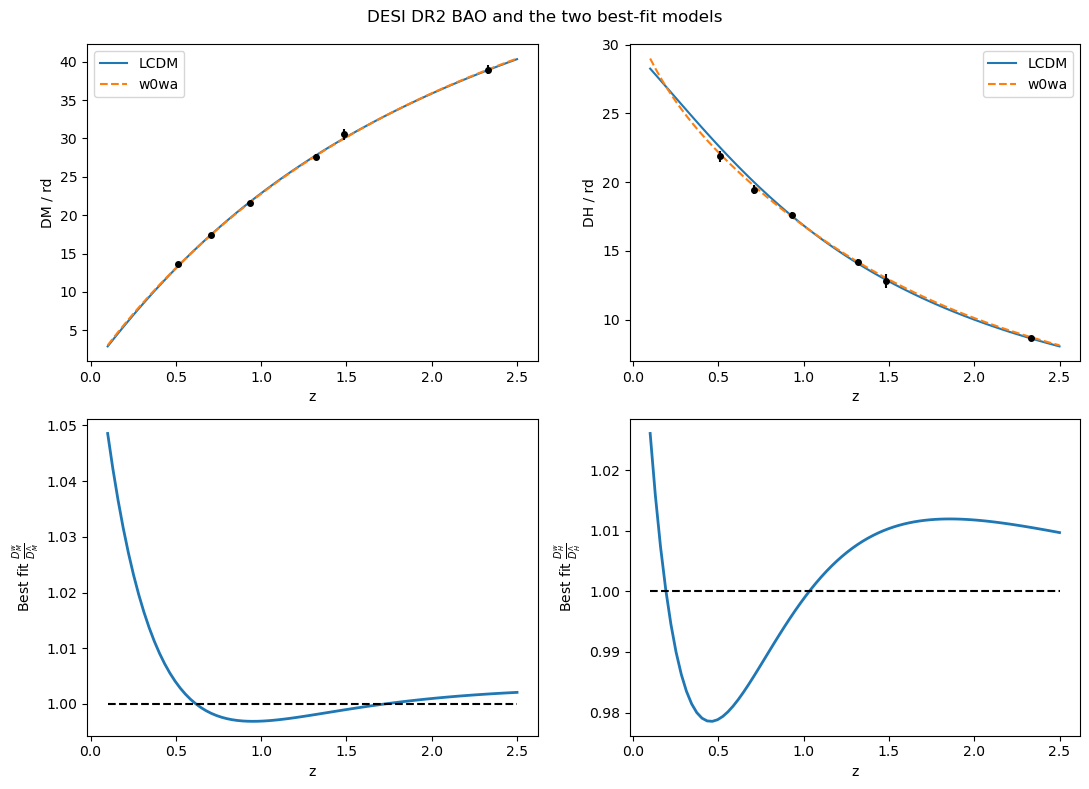

In [20]:
# Provided: the BAO Hubble diagram with the two best-fit models.
zz = np.linspace(0.1, 2.5, 80)
dm_l = np.array([float(cosmo_lcdm.DM(z))/RD for z in zz])
dh_l = np.array([float(cosmo_lcdm.DH(z))/RD for z in zz])
dm_w = np.array([float(cosmo_w0wa.DM(z))/RD for z in zz])
dh_w = np.array([float(cosmo_w0wa.DH(z))/RD for z in zz])
fig, ax = plt.subplots(2, 2, figsize=(11, 8))
ax=ax.flatten()
plt.sca(ax[0]);plt.plot(zz, dm_l, label='LCDM'); ax[0].plot(zz, dm_w, '--', label='w0wa')
plt.sca(ax[1]);plt.plot(zz, dh_l, label='LCDM'); ax[1].plot(zz, dh_w, '--', label='w0wa')


z_desi=[];dm_desi=[];dh_desi=[]
dm_desi_sigma=[]
for tr, z, obs, v1, s1, v2, s2, rho in desi:
    z_desi.append(z)
    dm_desi.append(v1)
    dm_desi_sigma.append(s1)
    dh_desi.append(v2)
    
#dm_l_ = np.array([float(cosmo_lcdm.DM(z))/RD for z in z_desi])
#dh_l = np.array([float(cosmo_lcdm.DH(z))/RD for z in z_desi])

for tr, z, obs, v1, s1, v2, s2, rho in desi:
    if obs == 'DM_DH':
        ax[0].errorbar(z, v1, s1, fmt='o', color='k', ms=4)
        ax[1].errorbar(z, v2, s2, fmt='o', color='k', ms=4)
        
#dm_l_ = np.array([float(cosmo_lcdm.DM(z))/RD for
## ratio
#ax[2].errorbar(z_desi, dm_desi/dm_l_, dm_desi_sigma, fmt='o', color='k', ms=4)
ax[2].plot(zz,dm_w/dm_l,lw=2); ax[2].plot(zz,zz*0+1,'k--')
ax[3].plot(zz,dh_w/dh_l,lw=2); ax[3].plot(zz,zz*0+1,'k--') 

ax[0].set_xlabel('z'); ax[0].set_ylabel('DM / rd'); ax[0].legend()
ax[1].set_xlabel('z'); ax[1].set_ylabel('DH / rd'); ax[1].legend()
ax[2].set_xlabel('z'); ax[2].set_ylabel(r'Best fit $\frac{D_M^{w}}{D_M^{\Lambda}}$');
ax[3].set_xlabel('z'); ax[3].set_ylabel(r'Best fit $\frac{D_H^{w}}{D_H^{\Lambda}}$'); 

ax[1].legend()
fig.suptitle('DESI DR2 BAO and the two best-fit models'); plt.tight_layout(); plt.show()

### Task 2. Where to add one new point
If the truth is $\Lambda$CDM, the separation the current data already provides
between the two best-fit models is
$$ S_0=\sum_{\rm DESI}\big[(\text{model}_\Lambda-\text{model}_{w_0w_a})/\sigma\big]^2 . $$
A new $D_M/r_d$ point at redshift $z$ with fractional error $f$ adds
$$ \Delta S(z,f)=\Big[\frac{D_M^{\Lambda}(z)-D_M^{w_0w_a}(z)}{f\,D_M^{\Lambda}(z)}\Big]^2 . $$
For each candidate redshift, find the $f$ that brings $S_0+\Delta S$ to $25$
(5 sigma), and pick the redshift where the models differ most (the largest
allowed $f$).

current separation sqrt(S0) = 2.22 sigma


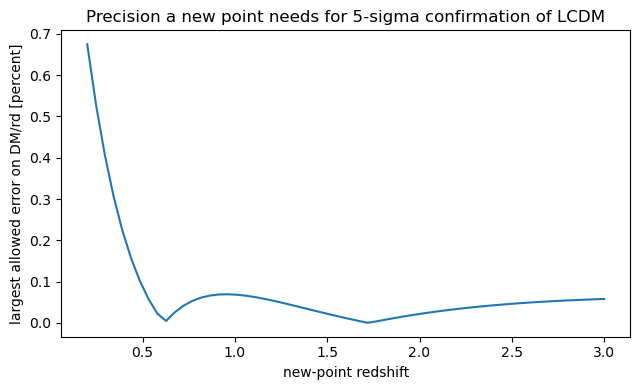

best new-point redshift ~ 0.20  (models differ most there)
required error on DM/rd there: 0.67 percent


In [5]:
def sep_point(row):
    tr, z, obs, v1, s1, v2, s2, rho = row
    if obs == 'DV':
        return ((float(cosmo_lcdm.DV(z)) - float(cosmo_w0wa.DV(z)))/RD/s1)**2
    dm_a = float(cosmo_lcdm.DM(z))/RD; dh_a = float(cosmo_lcdm.DH(z))/RD
    dm_b = float(cosmo_w0wa.DM(z))/RD; dh_b = float(cosmo_w0wa.DH(z))/RD
    C = np.array([[s1*s1, rho*s1*s2], [rho*s1*s2, s2*s2]])
    d = np.array([dm_a - dm_b, dh_a - dh_b])
    return float(d @ np.linalg.inv(C) @ d)

S0 = sum(sep_point(r) for r in desi)
print('current separation sqrt(S0) = %.2f sigma' % np.sqrt(S0))
need = 25.0 - S0

z_new = np.linspace(0.2, 3.0, 60)
allowed_f = []
for zn in z_new:
    dm_a = float(cosmo_lcdm.DM(zn))/RD; dm_b = float(cosmo_w0wa.DM(zn))/RD
    diff = abs(dm_a - dm_b)/dm_a          # fractional model difference in DM/rd
    allowed_f.append(diff/np.sqrt(need) if need > 0 else np.nan)
allowed_f = np.array(allowed_f)

plt.figure(figsize=(6.5, 4))
plt.plot(z_new, 100*allowed_f)
plt.xlabel('new-point redshift'); plt.ylabel('largest allowed error on DM/rd [percent]')
plt.title('Precision a new point needs for 5-sigma confirmation of LCDM')
plt.tight_layout(); plt.show()

ibest = int(np.nanargmax(allowed_f))
print('best new-point redshift ~ %.2f  (models differ most there)' % z_new[ibest])
print('required error on DM/rd there: %.2f percent' % (100*allowed_f[ibest]))

**Which redshift did you choose for the new point, and what minimum error does
it need for a 5-sigma confirmation of $\Lambda$CDM?** Explain why that redshift
is favoured: look at the Hubble-diagram plot and say where the two models
diverge most, and connect it to the value of $w_0$ in the best fit (how far it
sits from $-1$, and at what redshifts that matters most). Finally, in one
sentence: given the precision your answer demands, does a single new BAO point
realistically settle $\Lambda$CDM versus evolving dark energy, or not?